In [147]:
import sys
from pathlib import Path

# Ensure project root is on sys.path
_project_root = (
    str(Path(__file__).resolve().parent.parent)
    if "__file__" in dir()
    else str(Path.cwd().parent)
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS, evaluations_dir
import figures_paper.figure_config as figure_config
importlib.reload(figure_config)
from figures_paper.figure_config import (
    get_model_label,
    get_context_label,
    get_cytof_marker_label,
    configure_axis_spines,
    MODEL_COLORS,
    REF_PALETTE,
    REF_LABELS,
    OBS_LABELS,
    CONDITION_LABELS,
    REF_DISPLAY_MAP,
    BARPLOT_REF_LINE_STYLES,
    BARPLOT_REF_LINE_COLORS,
)
from annotation_utils import generate_subtype_annotations


## Configuration

In [148]:
# ── Model ─────────────────────────────────────────────────────────────
data = "dream_cytof"
figure = "figure3"

models = {
    "DMM": "EGFR_MAPK__logobs",
}

selected_model = "DMM"
selected_context = "cytof_init"

## Load trajectory data

In [192]:
# Load trajectories from all specified models
traj_dfs = []
for label, model_name in models.items():
    path = evaluations_dir / model_name / data / f"trajectories_{figure}.csv"
    if not path.exists():
        print(f"  ⚠ Skipping {label}: {path} not found")
        continue
    df = pd.read_csv(path, index_col=0)
    df["model_label"] = label
    traj_dfs.append(df)
    print(
        f"[{label}] {len(df):,} rows, "
        f"{df['sample'].nunique()} cell lines, "
        f"refs: {sorted(df['ref'].unique())}, "
        f"contexts: {sorted(df['context'].unique())}"
    )

traj = pd.concat(traj_dfs, ignore_index=True)

# Summary
print(f"\nCombined: {len(traj):,} rows")
print(f"  Observables : {sorted(traj['observable'].unique())}")
print(f"  Conditions  : {sorted(traj['condition'].unique())}")
print(f"  Time points : {sorted(traj['time'].unique())}")
print(f"  Cell lines  : {traj['sample'].nunique()}")
print(f"  Datasets    : {sorted(traj['dataset'].unique())}")

# ── Load per-combo RMSE from by_cl_cond_obs CSV ──────────────────────
by_path = evaluations_dir / models[selected_model] / data / f"by_cl_cond_obs_{figure}.csv"
by_cl = pd.read_csv(by_path, index_col=0).rename(columns={"sample": "cell_line"})

by_dmm_val = by_cl[
    (by_cl["ref"] == "DMM")
    & (by_cl["context"] == selected_context)
    & (by_cl["dataset"] == "val")
]
combo_rmse = by_dmm_val.groupby(["cell_line", "condition", "observable"])["rmse"].median().sort_values()

# ── Select 3 representative combos at RMSE quartiles ──────────────────
q25, q50, q75 = combo_rmse.quantile([0.25, 0.5, 0.75])
combo_q25 = (combo_rmse - q25).abs().idxmin()
combo_q50 = (combo_rmse - q50).abs().idxmin()
combo_q75 = (combo_rmse - q75).abs().idxmin()

HIGHLIGHT_CELL_LINES = [combo_q25[0], combo_q50[0], combo_q75[0]]

print(f"\nRepresentative combos (Q25 / Q50 / Q75 of median per-seed RMSE on val set):")
for tag, combo in [("Q25", combo_q25), ("Q50", combo_q50), ("Q75", combo_q75)]:
    cl, cond, obs = combo
    obs_label = OBS_LABELS.get(obs, obs)
    cond_label = CONDITION_LABELS.get(cond, cond)
    cl_display = cl.replace("c", "", 1)
    print(f"  {tag} → {cl_display} / {cond_label} / {obs_label}  (RMSE = {combo_rmse[combo]:.4f})")
print(f"  Range: {combo_rmse.min():.4f} – {combo_rmse.max():.4f} ({len(combo_rmse)} combos)")

[DMM] 196,962 rows, 63 cell lines, refs: ['DMM', 'avg_model', 'elasticnet', 'lasso', 'linreg', 'sample'], contexts: ['cytof_init', 'multimodal']

Combined: 196,962 rows
  Observables : ['pERBB2_Y1248_obs', 'pERK_Y204_obs', 'pMEK_S222_obs', 'pRPS6KA1_S380_obs']
  Conditions  : ['EGF', 'iEGFR', 'iMEK']
  Time points : [np.float64(0.0), np.float64(5.5), np.float64(7.0), np.float64(9.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(23.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(60.0)]
  Cell lines  : 63
  Datasets    : ['train', 'val']

Representative combos (Q25 / Q50 / Q75 of median per-seed RMSE on val set):
  Q25 → ZR75B / EGF + iEGFR / phospho MEK  (RMSE = 0.2623)
  Q50 → CAL120 / EGF / phospho p90$^{rsk}$  (RMSE = 0.3665)
  Q75 → HCC1143 / EGF / phospho ERK  (RMSE = 0.5591)
  Range: 0.1240 – 1.1266 (60 combos)


## Helper functions

In [195]:
def plot_trajectory(
    traj,
    cell_line,
    condition,
    observable,
    model_label=None,
    context=None,
    refs=None,
    ax=None,
    show_seeds=True,
    title=None,
    rmse_data=None,
):
    """
    Plot a single trajectory: experimental data (obs) + model simulations.

    Parameters
    ----------
    traj : DataFrame
        Full trajectory table.
    cell_line, condition, observable : str
        Which trajectory to plot.
    model_label : str, optional
        Filter to a specific model (e.g. "DMM + tEGFR"). None = first available.
    context : str, optional
        Filter to a specific context (e.g. "cytof_init"). None = first available.
    refs : list of str, optional
        Which reference methods to show. None = all.
    ax : matplotlib Axes, optional
    show_seeds : bool
        If True, show individual random-seed trajectories for DMM.
    title : str, optional
        Custom title. Auto-generated if None.
    rmse_data : dict, optional
        RMSE values by ref name to display as annotations.
    """
    sub = traj[
        (traj["sample"] == cell_line)
        & (traj["condition"] == condition)
        & (traj["observable"] == observable)
    ].copy()

    if model_label is not None:
        sub = sub[sub["model_label"] == model_label]
    else:
        model_label = sub["model_label"].iloc[0] if len(sub) else "?"

    if context is not None:
        sub = sub[sub["context"] == context]
    else:
        context = sub["context"].iloc[0] if len(sub) else "?"

    if refs is not None:
        sub = sub[sub["ref"].isin(refs)]

    if sub.empty:
        print(f"No data for {cell_line} / {condition} / {observable}")
        return ax

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.5))

    # --- Experimental data from obs column (in DMM rows) ---
    if "obs" in sub.columns:
        dmm_obs = sub[sub["ref"] == "DMM"]
        if not dmm_obs.empty and dmm_obs["obs"].notna().any():
            exp_mean = dmm_obs.groupby("time")["obs"].mean()
            ax.plot(
                exp_mean.index, exp_mean.values,
                color=REF_PALETTE.get("obs", "#2ca02c"), marker="o", markersize=5,
                linewidth=2.2, label=REF_LABELS.get("obs", "Experimental"), zorder=10,
            )

    # --- Sample reference (positive control) ---
    sample_ref = sub[sub["ref"] == "sample"]
    if not sample_ref.empty:
        sample_mean = sample_ref.groupby("time")["sim"].mean()
        sample_label = REF_DISPLAY_MAP.get("sample", REF_LABELS.get("sample", "Sample ref"))
        ax.plot(
            sample_mean.index, sample_mean.values,
            color=BARPLOT_REF_LINE_COLORS.get("positive control", REF_PALETTE.get("sample", "#98df8a")),
            linewidth=1.3, linestyle=BARPLOT_REF_LINE_STYLES.get("positive control", "--"),
            alpha=0.7, label=sample_label, zorder=7,
        )

    # --- DMM: individual random-seed trajectories + mean/variance ---
    dmm = sub[sub["ref"] == "DMM"]
    if not dmm.empty:
        # Individual seed trajectories (background)
        if show_seeds:
            seed_cols = [c for c in ["job", "features"] if c in dmm.columns]
            if seed_cols:
                first_seed = True
                for _, seed_df in dmm.groupby(seed_cols):
                    seed_ts = seed_df.sort_values("time")
                    ax.plot(
                        seed_ts["time"], seed_ts["sim"],
                        color=REF_PALETTE["DMM"], alpha=0.12,
                        linewidth=0.7, zorder=3,
                        label=REF_LABELS["DMM"] + " (random seeds)" if first_seed else None,
                    )
                    first_seed = False

        # Mean and variance across seeds (foreground)
        dmm_stats = dmm.groupby("time")["sim"].agg(["mean", "std"]).reset_index()
        ax.fill_between(
            dmm_stats["time"],
            dmm_stats["mean"] - dmm_stats["std"],
            dmm_stats["mean"] + dmm_stats["std"],
            color=REF_PALETTE["DMM"], alpha=0.22, linewidth=0, zorder=4,
            label=REF_LABELS["DMM"] + " (±1 SD)",
        )
        ax.plot(
            dmm_stats["time"], dmm_stats["mean"],
            color=REF_PALETTE["DMM"], linewidth=2.8,
            linestyle="-", label=REF_LABELS["DMM"] + " (mean)", zorder=6,
        )

    # --- Other references (avg_model as negative control, regressors) ---
    for ref_name in ["avg_model", "linreg", "lasso", "elasticnet"]:
        ref_sub = sub[sub["ref"] == ref_name]
        if ref_sub.empty:
            continue
        if refs is not None and ref_name not in refs:
            continue
        ref_mean = ref_sub.groupby("time")["sim"].mean()
        
        # Apply control styling for avg_model
        if ref_name == "avg_model":
            control_label = REF_DISPLAY_MAP.get("avg_model", REF_LABELS.get("avg_model", "Avg. model"))
            color = BARPLOT_REF_LINE_COLORS.get("negative control", REF_PALETTE.get("avg_model", "grey"))
            linestyle = BARPLOT_REF_LINE_STYLES.get("negative control", "--")
        else:
            control_label = REF_LABELS.get(ref_name, ref_name)
            color = REF_PALETTE.get(ref_name, "grey")
            linestyle = "--"
        
        ax.plot(
            ref_mean.index, ref_mean.values,
            color=color, linewidth=1.5, linestyle=linestyle,
            label=control_label, zorder=2,
        )

    # --- Labels ---
    obs_label = OBS_LABELS.get(observable, observable)
    cond_label = CONDITION_LABELS.get(condition, condition)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel(f"{obs_label} [a.u.]")
    if title is None:
        cl_display = cell_line.replace("c", "", 1)
        title = f"{cl_display} — {cond_label}"
    ax.set_title(title, fontsize=11)

    # --- Configure axis styling: keep left/bottom spines, show ticks ---
    configure_axis_spines(ax, top=False, right=False, left=True, bottom=True)
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    # Add RMSE text annotations if provided
    if rmse_data:
        ymax = ax.get_ylim()[1]
        ymin = ax.get_ylim()[0]
        y_range = ymax - ymin
        
        # Build text lines for controls and linear regression
        metric_lines = []
        
        # Negative control (avg_model)
        if "avg_model" in rmse_data:
            rmse_val = rmse_data["avg_model"]
            metric_lines.append(f"Neg control: {rmse_val:.3f}")
        
        # Positive control (sample)
        if "sample" in rmse_data:
            rmse_val = rmse_data["sample"]
            metric_lines.append(f"Pos control: {rmse_val:.3f}")
        
        # Linear regression (elasticnet)
        if "elasticnet" in rmse_data:
            rmse_val = rmse_data["elasticnet"]
            metric_lines.append(f"Lin reg: {rmse_val:.3f}")
        
        # Aggregate trajectories and place text consistently
        if metric_lines:
            sim_vals = []
            if "sim" in sub.columns and sub["sim"].notna().any():
                sim_vals.append(sub["sim"].mean())
            if "obs" in sub.columns and sub["obs"].notna().any():
                sim_vals.append(sub["obs"].mean())
            avg_level = float(np.mean(sim_vals)) if sim_vals else (ymin + y_range / 2)
            use_top = avg_level <= 3.0
            y_pos = ymax - 0.1 * y_range if use_top else ymin + 0.1 * y_range
            x_left, x_right = ax.get_xlim()
            x_center = 0.5 * (x_left + x_right)
            text_lines = ["RMSE:"] + metric_lines
            text_str = "\n".join(text_lines)
            ax.text(
                x_center,
                y_pos,
                text_str,
                ha="center", va="top" if use_top else "bottom",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none"),
            )

    return ax


## 1. Representative validation trajectories

Three validation-set trajectories selected at the Q10, Q50, and Q90
of the per-combo (cell line × condition × observable) RMSE distribution.
Each panel shows experimental data, DMM mean ± SD, and regression baselines.

  Q10 (best): ('cCAL120', 'iEGFR', 'pMEK_S222_obs')  RMSE = 0.2040
  Q50 (median): ('cCAL120', 'EGF', 'pRPS6KA1_S380_obs')  RMSE = 0.3665
  Q90 (worst): ('cKPL1', 'iMEK', 'pRPS6KA1_S380_obs')  RMSE = 0.7366


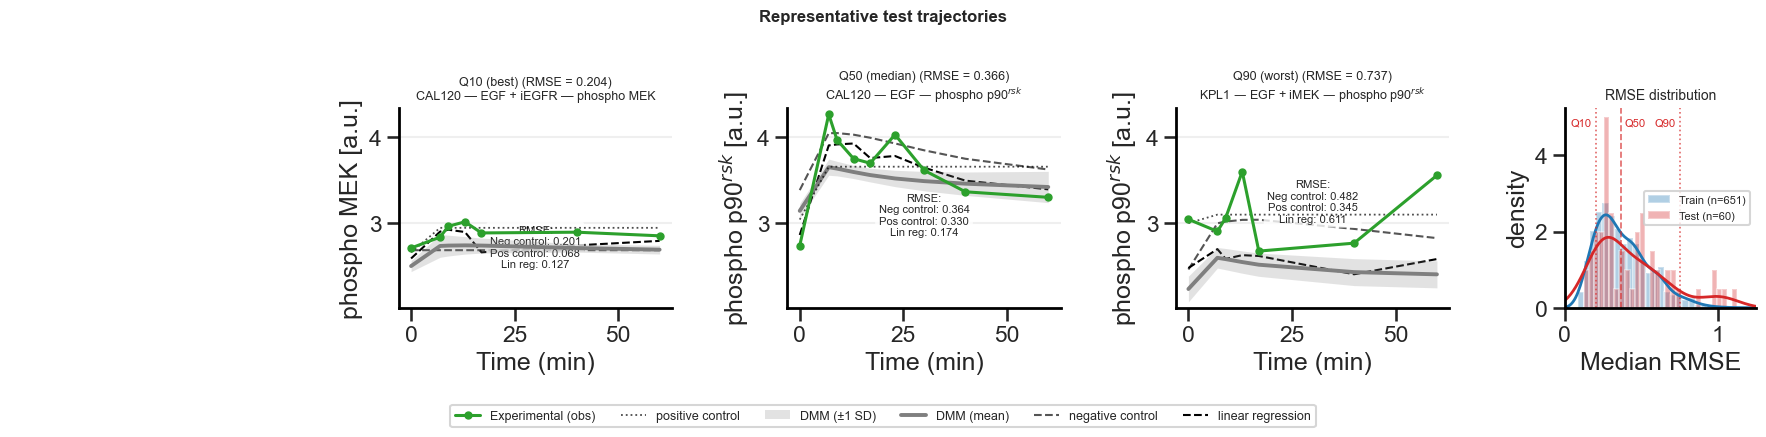

In [ ]:
# ── Select 3 representative val combos at RMSE quantiles ──────────────
# combo_rmse (median per-seed RMSE from by_cl_cond_obs) was computed in
# the data-loading cell above; reuse it directly.
q10_v, q50_v, q90_v = combo_rmse.quantile([0.10, 0.50, 0.90])
rep_combos = {}
for tag, qv in [("Q10 (good)", q10_v), ("Q50 (average)", q50_v), ("Q90 (bad)", q90_v)]:
    idx = (combo_rmse - qv).abs().idxmin()
    rep_combos[tag] = idx
    print(f"  {tag}: {idx}  RMSE = {combo_rmse[idx]:.4f}")

# ── Plot 3 trajectories + empty axis (left) + RMSE distribution (right) ───────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), gridspec_kw={"width_ratios": [1, 1, 1, 1, 0.7]})
empty_ax = axes[0]
empty_ax.axis("off")
traj_axes = axes[1:4]
dist_ax = axes[4]

for ax, (tag, (cl, cond, obs)) in zip(traj_axes, rep_combos.items()):
    # Get RMSE values for all refs for this combination on val set
    rmse_data = {}
    for ref_name in ["avg_model", "sample", "elasticnet"]:
        rmse_rows = by_cl[
            (by_cl["cell_line"] == cl)
            & (by_cl["condition"] == cond)
            & (by_cl["observable"] == obs)
            & (by_cl["ref"] == ref_name)
            & (by_cl["context"] == selected_context)
            & (by_cl["dataset"] == "val")
        ]
        if not rmse_rows.empty:
            rmse_data[ref_name] = rmse_rows["rmse"].median()
    
    plot_trajectory(
        traj, cl, cond, obs,
        model_label=selected_model,
        context=selected_context,
        refs=["sample", "DMM", "avg_model", "elasticnet"],
        ax=ax,
        show_seeds=False,
        rmse_data=rmse_data,
    )
    obs_label = OBS_LABELS.get(obs, obs)
    cond_label = CONDITION_LABELS.get(cond, cond)
    cl_display = cl.replace("c", "", 1)
    rmse_val = combo_rmse[(cl, cond, obs)]
    ax.set_title(f"{tag} (RMSE = {rmse_val:.3f})\n{cl_display} — {cond_label} — {obs_label}", fontsize=9)

# ── Consistent y-axis across all trajectory panels ─────────────────────
ymin = min(ax.get_ylim()[0] for ax in traj_axes)
ymax = max(ax.get_ylim()[1] for ax in traj_axes)
for ax in traj_axes:
    ax.set_ylim(ymin, ymax)

# Single legend (trajectory panels)
handles, labels = traj_axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(),
    loc="lower center", ncol=len(by_label),
    fontsize=9, frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)
for ax in traj_axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

# ── RMSE distribution on the right axis ────────────────────────────────
dmm_all = by_cl[
    (by_cl["ref"] == "DMM") & (by_cl["context"] == selected_context)
]
combo_rmse_all = (
    dmm_all.groupby(["cell_line", "condition", "observable", "dataset"])["rmse"]
    .median()
    .reset_index()
 )

for ds, color, label in [("train", "#1f77b4", "Train"), ("val", "#d62728", "Test")]:
    subset = combo_rmse_all[combo_rmse_all["dataset"] == ds]["rmse"]
    dist_ax.hist(subset, bins=30, alpha=0.35, color=color, label=f"{label} (n={len(subset)})", edgecolor="white", density=True)
    sns.kdeplot(subset, ax=dist_ax, color=color, linewidth=2)

# Mark test quantiles
val_rmse = combo_rmse_all[combo_rmse_all["dataset"] == "val"]["rmse"]
for q, ls in [(0.10, ":"), (0.5, "--"), (0.90, ":")]:
    qv = val_rmse.quantile(q)
    dist_ax.axvline(qv, color="#d62728", linestyle=ls, alpha=0.7, linewidth=1.2)
    x_align = "left" if q == 0.5 else "right"
    x_offset = 3 if q == 0.5 else -3
    dist_ax.annotate(
        f"Q{int(q*100)}",
        xy=(qv, 0.95),
        xycoords=dist_ax.get_xaxis_transform(),
        xytext=(x_offset, 0),
        textcoords="offset points",
        ha=x_align, va="top", fontsize=8, color="#d62728",
    )

dist_ax.set_xlim(0, 1.25)
dist_ax.set_xlabel("Median RMSE")
dist_ax.set_ylabel("density")
dist_ax.set_title("RMSE distribution", fontsize=10)
dist_ax.legend(fontsize=8)
configure_axis_spines(dist_ax, top=False, right=False, left=True, bottom=True)
dist_ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
dist_ax.grid(False)

fig.suptitle("Representative test trajectories", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(str(Path(_project_root) / "figures_paper" / "traj_representative_val.pdf"), bbox_inches="tight", dpi=150)
plt.show()


## 2. Train vs val RMSE scatter

Scatter of median RMSE across cell lines: x = train, y = val.
Marker shape encodes the observable, colour encodes the condition.
Crosshairs show ± 1 SD across random seeds.
Points above the diagonal indicate a generalisation gap.

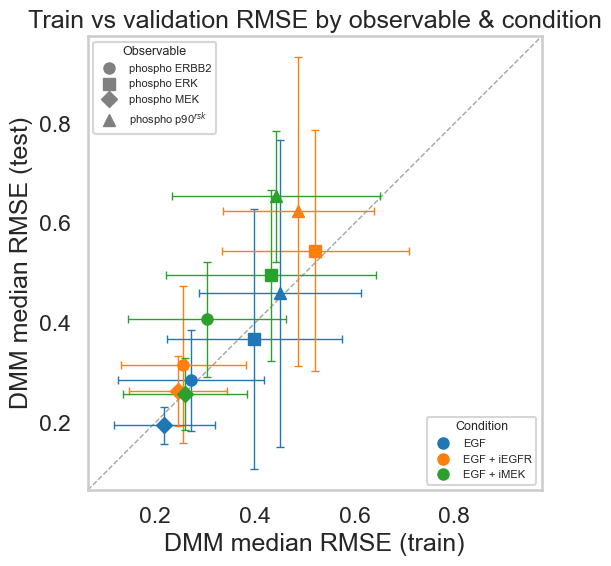

In [177]:
# --- Train vs Val RMSE scatter (DMM only) ---
from matplotlib.lines import Line2D

dmm = by_cl[
    (by_cl["ref"] == "DMM") & (by_cl["context"] == selected_context)
].copy()

# Median and SD of RMSE per (observable, condition, dataset) across cell lines
stats = (
    dmm.groupby(["observable", "condition", "dataset"])["rmse"]
    .agg(["median", "std"])
    .reset_index()
)

train_stats = stats[stats["dataset"] == "train"].rename(
    columns={"median": "median_train", "std": "std_train"}
).drop(columns="dataset")
val_stats = stats[stats["dataset"] == "val"].rename(
    columns={"median": "median_val", "std": "std_val"}
).drop(columns="dataset")

scatter_df = train_stats.merge(val_stats, on=["observable", "condition"])

# Marker shapes per observable
obs_markers = {
    "pERBB2_Y1248_obs": "o",
    "pERK_Y204_obs": "s",
    "pMEK_S222_obs": "D",
    "pRPS6KA1_S380_obs": "^",
}

# Condition colours
cond_colors = {
    "EGF": "#1f77b4",
    "iEGFR": "#ff7f0e",
    "iMEK": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in scatter_df.iterrows():
    obs = row["observable"]
    cond = row["condition"]
    x, y = row["median_train"], row["median_val"]
    xerr, yerr = row["std_train"], row["std_val"]
    ax.errorbar(
        x, y, xerr=xerr, yerr=yerr,
        fmt=obs_markers.get(obs, "o"),
        color=cond_colors.get(cond, "grey"),
        markersize=8, capsize=3, capthick=1, elinewidth=1,
        zorder=3,
    )

# Diagonal reference line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "k--", alpha=0.4, lw=1, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("DMM median RMSE (train)")
ax.set_ylabel("DMM median RMSE (test)")
ax.set_title("Train vs validation RMSE by observable & condition")
ax.set_aspect("equal")

# Build legends
obs_handles = [
    Line2D([], [], marker=m, color="grey", linestyle="", markersize=8,
           label=OBS_LABELS.get(o, o))
    for o, m in obs_markers.items()
]
cond_handles = [
    Line2D([], [], marker="o", color=c, linestyle="", markersize=8,
           label=CONDITION_LABELS.get(c_key, c_key))
    for c_key, c in cond_colors.items()
]

leg1 = ax.legend(handles=obs_handles, title="Observable", loc="upper left",
                 fontsize=8, title_fontsize=9)
ax.add_artist(leg1)
ax.grid(False)
ax.legend(handles=cond_handles, title="Condition", loc="lower right",
          fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()